WITHOUT SKLEARN

In [1]:
import numpy as np
import pandas as pd
from math import pi, exp
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("Assign10_Iris.csv")

# Fix column names (remove spaces + lowercase)
df.columns = df.columns.str.strip().str.lower()

print("Columns in dataset:", df.columns)

# Show first 5 rows
print("\nFirst 5 Rows of Dataset:\n")
print(df.head())

Columns in dataset: Index(['id', 'sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm',
       'species'],
      dtype='object')

First 5 Rows of Dataset:

   id  sepallengthcm  sepalwidthcm  petallengthcm  petalwidthcm      species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [3]:
df = df.drop_duplicates()

In [4]:
def summarize_by_class(df):
    summaries = {}
    for c in df['species'].unique():
        class_data = df[df['species'] == c].drop('species', axis=1)
        summaries[c] = [(class_data[col].mean(), class_data[col].std()) for col in class_data.columns]
    return summaries

In [5]:
def calculate_probability(x, mean, std):
    if std == 0:
        return 1 if x == mean else 0
    exponent = -((x - mean)**2) / (2 * std**2)
    return (1 / (std * np.sqrt(2 * pi))) * exp(exponent)


In [6]:
def calculate_class_probability(row, summaries, class_label):
    total = 1
    features = row[:-1]
    for i in range(len(features)):
        mean, std = summaries[class_label][i]
        total *= calculate_probability(features[i], mean, std)
    return total


In [7]:
def predict(row, summaries):
    probs = {}
    for c in summaries:
        probs[c] = calculate_class_probability(row, summaries, c)
    return max(probs, key=probs.get)


In [8]:
# Train model
summaries = summarize_by_class(df)


In [9]:
predictions = df.apply(lambda row: predict(row.values, summaries), axis=1)

In [10]:
results = pd.DataFrame({
    'Actual': df['species'],
    'Predicted': predictions
})

In [11]:
results['Status'] = np.where(results['Actual'] == results['Predicted'], 'Correct', 'Wrong')

print("\nSample Results:\n")
print(results.head(10))


Sample Results:

        Actual    Predicted   Status
0  Iris-setosa  Iris-setosa  Correct
1  Iris-setosa  Iris-setosa  Correct
2  Iris-setosa  Iris-setosa  Correct
3  Iris-setosa  Iris-setosa  Correct
4  Iris-setosa  Iris-setosa  Correct
5  Iris-setosa  Iris-setosa  Correct
6  Iris-setosa  Iris-setosa  Correct
7  Iris-setosa  Iris-setosa  Correct
8  Iris-setosa  Iris-setosa  Correct
9  Iris-setosa  Iris-setosa  Correct


In [12]:
correct = results[results['Status'] == 'Correct']
incorrect = results[results['Status'] == 'Wrong']

print("\nCorrect Predictions:\n")
print(correct.head(10))

print("\nIncorrect Predictions:\n")
print(incorrect)


Correct Predictions:

        Actual    Predicted   Status
0  Iris-setosa  Iris-setosa  Correct
1  Iris-setosa  Iris-setosa  Correct
2  Iris-setosa  Iris-setosa  Correct
3  Iris-setosa  Iris-setosa  Correct
4  Iris-setosa  Iris-setosa  Correct
5  Iris-setosa  Iris-setosa  Correct
6  Iris-setosa  Iris-setosa  Correct
7  Iris-setosa  Iris-setosa  Correct
8  Iris-setosa  Iris-setosa  Correct
9  Iris-setosa  Iris-setosa  Correct

Incorrect Predictions:

             Actual        Predicted Status
106  Iris-virginica  Iris-versicolor  Wrong


In [13]:
labels = df['species'].unique()
cm = confusion_matrix(df['species'], predictions, labels=labels)

print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[50  0  0]
 [ 0 50  0]
 [ 0  1 49]]


In [14]:
total = cm.sum()

for i, label in enumerate(labels):
    TP = cm[i][i]
    FN = sum(cm[i]) - TP
    FP = sum(cm[:, i]) - TP
    TN = total - (TP + FP + FN)

    accuracy = (TP + TN) / total
    error_rate = 1 - accuracy
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    print(f"\nClass: {label}")
    print("TP:", TP, "FP:", FP, "TN:", TN, "FN:", FN)
    print("Accuracy:", accuracy)
    print("Error Rate:", error_rate)
    print("Precision:", precision)
    print("Recall:", recall)




Class: Iris-setosa
TP: 50 FP: 0 TN: 100 FN: 0
Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0

Class: Iris-versicolor
TP: 50 FP: 1 TN: 99 FN: 0
Accuracy: 0.9933333333333333
Error Rate: 0.00666666666666671
Precision: 0.9803921568627451
Recall: 1.0

Class: Iris-virginica
TP: 49 FP: 0 TN: 100 FN: 1
Accuracy: 0.9933333333333333
Error Rate: 0.00666666666666671
Precision: 1.0
Recall: 0.98


In [15]:
# Enter your own flower values
new_flower = [5.1, 3.5, 1.4, 0.2]

# Convert to numpy array (optional)
new_flower = np.array(new_flower)

# Predict class
prediction = predict(np.append(new_flower, None), summaries)

print("\nManual Input Flower:", new_flower)
print("Predicted Species:", prediction)


Manual Input Flower: [5.1 3.5 1.4 0.2]
Predicted Species: Iris-setosa


WITH SKLEARN

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

In [17]:
df = pd.read_csv("Assign10_Iris.csv")

# Fix column names
df.columns = df.columns.str.strip().str.lower()

print("Columns in dataset:", df.columns)

# Show first 5 rows
print("\nFirst 5 Rows of Dataset:\n")
print(df.head())

Columns in dataset: Index(['id', 'sepallengthcm', 'sepalwidthcm', 'petallengthcm', 'petalwidthcm',
       'species'],
      dtype='object')

First 5 Rows of Dataset:

   id  sepallengthcm  sepalwidthcm  petallengthcm  petalwidthcm      species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [18]:
df = df.drop_duplicates()

In [19]:
X = df.drop('species', axis=1)
y = df['species']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [21]:
predictions = model.predict(X_test)

In [22]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

results['Status'] = np.where(results['Actual'] == results['Predicted'], 'Correct', 'Wrong')

print("\nSample Results:\n")
print(results.head(10))


Sample Results:

            Actual        Predicted   Status
0  Iris-versicolor  Iris-versicolor  Correct
1      Iris-setosa      Iris-setosa  Correct
2   Iris-virginica   Iris-virginica  Correct
3  Iris-versicolor  Iris-versicolor  Correct
4  Iris-versicolor  Iris-versicolor  Correct
5      Iris-setosa      Iris-setosa  Correct
6  Iris-versicolor  Iris-versicolor  Correct
7   Iris-virginica   Iris-virginica  Correct
8  Iris-versicolor  Iris-versicolor  Correct
9  Iris-versicolor  Iris-versicolor  Correct


In [23]:
correct = results[results['Status'] == 'Correct']
incorrect = results[results['Status'] == 'Wrong']

print("\nCorrect Predictions:\n")
print(correct.head(10))

print("\nIncorrect Predictions:\n")
print(incorrect)


Correct Predictions:

            Actual        Predicted   Status
0  Iris-versicolor  Iris-versicolor  Correct
1      Iris-setosa      Iris-setosa  Correct
2   Iris-virginica   Iris-virginica  Correct
3  Iris-versicolor  Iris-versicolor  Correct
4  Iris-versicolor  Iris-versicolor  Correct
5      Iris-setosa      Iris-setosa  Correct
6  Iris-versicolor  Iris-versicolor  Correct
7   Iris-virginica   Iris-virginica  Correct
8  Iris-versicolor  Iris-versicolor  Correct
9  Iris-versicolor  Iris-versicolor  Correct

Incorrect Predictions:

Empty DataFrame
Columns: [Actual, Predicted, Status]
Index: []


In [24]:
labels = df['species'].unique()
cm = confusion_matrix(y_test, predictions, labels=labels)

print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [25]:
total = cm.sum()

for i, label in enumerate(labels):
    TP = cm[i][i]
    FN = sum(cm[i]) - TP
    FP = sum(cm[:, i]) - TP
    TN = total - (TP + FP + FN)

    accuracy = (TP + TN) / total
    error_rate = 1 - accuracy
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    print(f"\nClass: {label}")
    print("TP:", TP, "FP:", FP, "TN:", TN, "FN:", FN)
    print("Accuracy:", accuracy)
    print("Error Rate:", error_rate)
    print("Precision:", precision)
    print("Recall:", recall)


Class: Iris-setosa
TP: 10 FP: 0 TN: 20 FN: 0
Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0

Class: Iris-versicolor
TP: 9 FP: 0 TN: 21 FN: 0
Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0

Class: Iris-virginica
TP: 11 FP: 0 TN: 19 FN: 0
Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


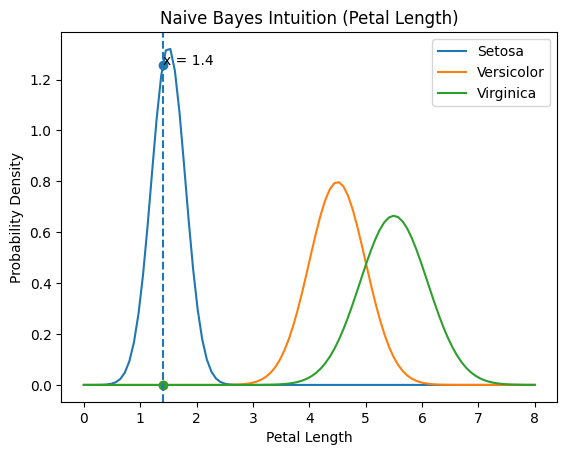

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# GAUSSIAN FUNCTION
# -----------------------------
def gaussian(x, mean, std):
    return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-((x - mean) ** 2) / (2 * std ** 2))

# -----------------------------
# X RANGE
# -----------------------------
x = np.linspace(0, 8, 100)

# -----------------------------
# CLASS DISTRIBUTIONS
# -----------------------------
setosa_mean, setosa_std = 1.5, 0.3
versicolor_mean, versicolor_std = 4.5, 0.5
virginica_mean, virginica_std = 5.5, 0.6

# Curves
setosa_curve = gaussian(x, setosa_mean, setosa_std)
versicolor_curve = gaussian(x, versicolor_mean, versicolor_std)
virginica_curve = gaussian(x, virginica_mean, virginica_std)

# -----------------------------
# NEW DATA POINT
# -----------------------------
new_value = 1.4

# Get y-values at x = 1.4
y_setosa = gaussian(new_value, setosa_mean, setosa_std)
y_versicolor = gaussian(new_value, versicolor_mean, versicolor_std)
y_virginica = gaussian(new_value, virginica_mean, virginica_std)

# -----------------------------
# PLOT
# -----------------------------
plt.figure()

plt.plot(x, setosa_curve, label="Setosa")
plt.plot(x, versicolor_curve, label="Versicolor")
plt.plot(x, virginica_curve, label="Virginica")

# Vertical line
plt.axvline(x=new_value, linestyle='--')

# Plot points on curves
plt.scatter(new_value, y_setosa)
plt.scatter(new_value, y_versicolor)
plt.scatter(new_value, y_virginica)

# Add text label
plt.text(new_value, max(y_setosa, y_versicolor, y_virginica),
         "x = 1.4", fontsize=10)

# Labels
plt.title("Naive Bayes Intuition (Petal Length)")
plt.xlabel("Petal Length")
plt.ylabel("Probability Density")
plt.legend()

plt.show()